This notebook follows section 2 of the tutorial that builds a basic Dynestyx state-space model. 

The model is defined as follows, with rho uniformly distributed between -0.9 and 0.9: 

In [2]:
# --- Setup / imports ---
import jax
import jax.numpy as jnp
import jax.random as random

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import arviz as az
import matplotlib.pyplot as plt

# Reproducible RNG key (JAX handles randomness explicitly via keys)
rng_key = random.PRNGKey(0)

print("jax       ", jax.__version__)
print("numpyro   ", numpyro.__version__)
print("arviz     ", az.__version__)
print("Setup OK — kernel is working.")

/Users/davidli/Documents/dynestyx-research/.venv/lib/python3.13/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


jax        0.9.2
numpyro    0.21.0
arviz      0.23.4
Setup OK — kernel is working.


![Linear-Gaussian state-space model](linear_gaussian_system.png)

In [ ]:
First create a Dynamical Model that describes the SSM

In [5]:
import jax.numpy as jnp
import dynestyx as dsx

from dynestyx.models import DynamicalModel  # noqa: F811

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))

# create the observation model as a callable mapping to a distribution
observation_model = lambda x, u, t: dist.MultivariateNormal(
    C @ x, 0.1**2 * jnp.eye(observation_dim)
)


def lti_model(rho=None, obs_times=None, obs_values=None, ctrl_times=None, ctrl_values=None, predict_times=None):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5), obs=rho)
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, 0.1**2 * jnp.eye(state_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample("f", dynamics, obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values, predict_times=predict_times)

Using the Predictive object to generate data

In [ ]:
import jax.random as jr
from numpyro.infer import Predictive
from dynestyx import DiscreteTimeSimulator

# For simulation: predict_times defines the time grid (no observed data yet)
predict_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = predict_times  # same times for controls

# create a synthetic control sequence as i.i.d. Gaussians
# (in practice, this would be an array of control inputs that we have observed)
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))

# For an autonomous system, we would simply omit ctrl_times and ctrl_values.
# Specifying rho_true means we are generating real data

rho_true = 0.3
with DiscreteTimeSimulator():
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )

    pred = predictive(rng_key=jr.PRNGKey(0), predict_times=predict_times, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

print(pred.keys())
print("Predicted states shape:", pred["f_states"].shape)
print("Predicted observations shape:", pred["f_observations"].shape)
print("Predicted times shape:", pred["f_times"].shape)


We now plot the generated data.

In dynamical data, our matrices have two redundant dimensions in num_simulations/num_samples, so we use a function to extract them out. 

In [ ]:
# Extract observations and states for plotting (and for inference below)
# obs_times and obs_values are the data we'll condition on for inference.

# Expected with num_samples=1 and n_sim=1:
# f_times: (1, 1, T), f_states: (1, 1, T, state_dim), f_observations: (1, 1, T, obs_dim)
obs_times = pred["f_times"][0, 0, :]
states = pred["f_states"][0, 0, :, :]
obs_values = pred["f_observations"][0, 0, :, 0]

# Plot
import matplotlib.pyplot as plt

#First establish the frame and the axes
fig, ax = plt.subplots(figsize=(10, 3))
#Plot all data in the first dimension of the hidden states with colour c0
#ax.plot will plot continuous lines/trajectories
ax.plot(obs_times, states[:, 0], label="latent x0", color="C0")
#Same thing for the second dimension of the hidden states with colour c1
ax.plot(obs_times, states[:, 1], label="latent x1", color="C1")
#ax.scatter plots discrete points 
ax.scatter(obs_times, obs_values, label="observations yt", color="C3", marker="x")
#Display tweaks
ax.legend()
ax.set_xlabel("time")
plt.tight_layout()
plt.show()

Inferences on Dynamical Models

We must wrap the mcmc code in a context window, here it is Discrete Time Simulator

In [10]:
from numpyro.infer import MCMC, NUTS

with DiscreteTimeSimulator():
    nuts_kernel = NUTS(lti_model)
    mcmc = MCMC(nuts_kernel, num_warmup=101, num_samples=101)
    mcmc.run(jr.PRNGKey(1), obs_times=obs_times, obs_values=obs_values, ctrl_times=ctrl_times, ctrl_values=ctrl_values)

posterior_sv = mcmc.get_samples()


# What did we infer? The Simulator unrolled the model, so we explicitly sampled latent states:
print(posterior_sv.keys())

# Print the shapes of each of the keys in the posterior samples
for key, value in posterior_sv.items():
    print(f"{key}: {value.shape}")

#The value of rho we inferred
print("Posterior rho mean:", (posterior_sv["rho"]))
print("Posterior rho mean:", float(jnp.mean(posterior_sv["rho"])))
print("True rho:", rho_true)

#For testing
print("f_states", posterior_sv["f_states"])

sample: 100%|██████████| 202/202 [00:01<00:00, 125.71it/s, 31 steps of size 1.49e-01. acc. prob=0.93]

dict_keys(['f_observations', 'f_states', 'f_times', 'f_x_0', 'f_x_JitTracer(int32[])', 'rho'])
f_observations: (101, 1, 100, 1)
f_states: (101, 1, 100, 2)
f_times: (101, 1, 100)
f_x_0: (101, 1, 2)
f_x_JitTracer(int32[]): (101, 99, 1, 2)
rho: (101,)
Posterior rho mean: [0.35712337 0.24794954 0.2166993  0.23837852 0.30306667 0.2778389
 0.34426492 0.3440997  0.3779866  0.33242697 0.29538596 0.2915581
 0.2964543  0.31295633 0.3073985  0.33160663 0.39260375 0.4375975
 0.41036814 0.3932404  0.36403614 0.40497148 0.33996838 0.31186122
 0.26578176 0.29161853 0.27406198 0.3019501  0.2643847  0.27397788
 0.29798943 0.32613325 0.37883484 0.37122858 0.3611197  0.3686791
 0.37294132 0.40370256 0.40143734 0.41737568 0.4096318  0.39752734
 0.40374577 0.3778746  0.34353125 0.36003453 0.34381586 0.32027203
 0.38608724 0.39142883 0.4041537  0.3031091  0.24617267 0.27180386
 0.29322433 0.25796992 0.3109755  0.2809338  0.32980472 0.32754195
 0.35807234 0.3642382  0.3994087  0.38721067 0.36043704 0.2844514

Plot posterior distribution for rho

In [ ]:
# use ArviZ to plot the posterior distribution for rho
import arviz as az

az.plot_posterior(posterior_sv["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.show()

Plotting Posterior Distribution

In [ ]:
# use ArviZ to plot the posterior distribution for rho
import arviz as az

az.plot_posterior(posterior_sv["rho"], hdi_prob=0.95, ref_val=rho_true)
plt.show()

Plotting inferred VS True States

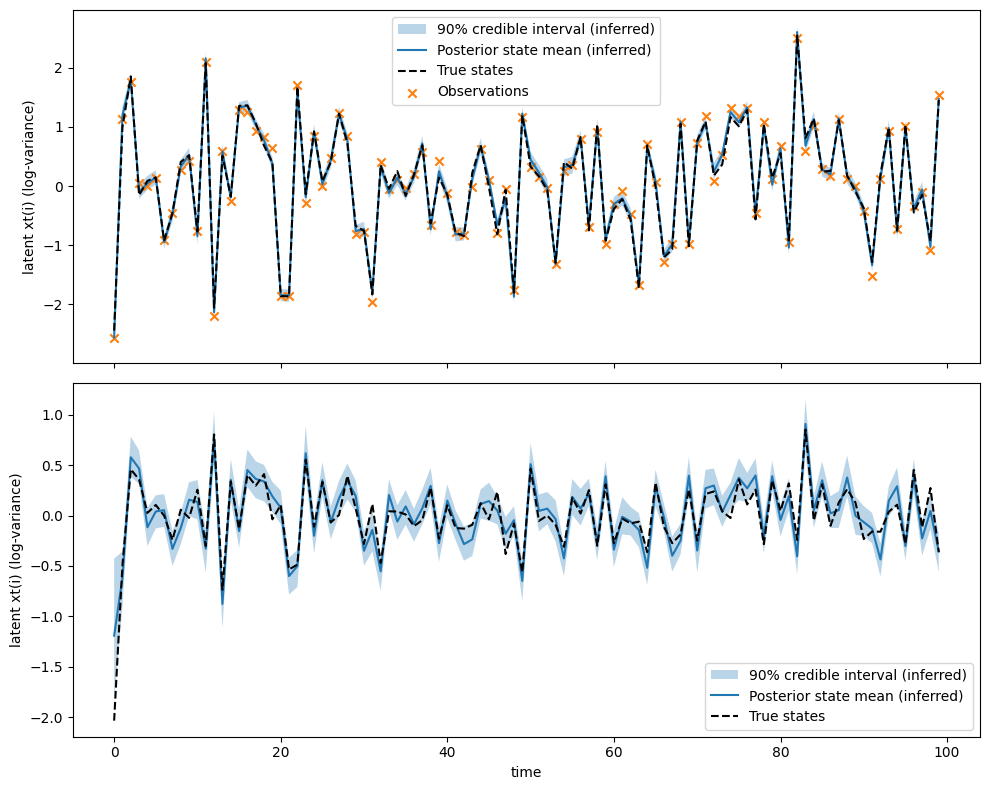

In [11]:
# Plot inferred states vs true states: posterior distribution over the latent trajectory,
# with a subplot for each latent variable/state dimension
inferred_states = posterior_sv["f_states"]  # (n_samples, n_sims, T+1, state_dim)
n_samples, _, T1, state_dim = inferred_states.shape

true_states = jnp.asarray(states)

# Compute posterior mean and credible intervals for the latent states at each time point
#axis=(0,1) means we are taking the mean and percentiles across 
# the first two dimensions (samples and sims as the values collapse into a scalar), 
# leaving us with a distribution over time and state dimension.
posterior_mean = inferred_states.mean(axis=(0,1))  # (T+1, state_dim)
q05 = jnp.percentile(inferred_states, 5, axis=(0,1))  # (T+1, state_dim)
q95 = jnp.percentile(inferred_states, 95, axis=(0,1))  # (T+1, state_dim)

#Create the figure and axes for plotting
#sharex means have subplots share the same x-axis (time axis),
fig, axes = plt.subplots(state_dim, 1, figsize=(10, 4 * state_dim), sharex=True)
#If state_dim > 1, axes is an array of individual axes
#If state_dim ==1, it is not so we need to make it an iterable array
if state_dim == 1:
    axes = [axes]  # make iterable

#Idea is to have 1 plot per state dimension
for i, ax in enumerate(axes):
    #fill_between command colours in a region, which is the credible interval
    #obs_times provides x axis below
    ax.fill_between(
        obs_times,
        q05[:, i],
        q95[:, i],
        alpha=0.3,
        label="90% credible interval (inferred)",
    )
    # Plot posterior mean as a line
    ax.plot(
        obs_times,
        posterior_mean[:, i],
        label="Posterior state mean (inferred)",
        color="C0",
    )
    # Plot true states as a dashed line
    ax.plot(
        obs_times, true_states[:, i], label="True states", color="black", linestyle="--"
    )
    #Since obs_values only exist for teh first dimension
    # Plot observations only on first subplot (if obs_values is appropriate size)
    #if 'obs_values" is defined in the local scope
    if i == 0 and "obs_values" in locals():
        #if obs_values has a shape
        #if obs_values is 1D or is matrix with a single column (shape (T,1))), plot it directly
        if hasattr(obs_values, "shape") and (
            obs_values.ndim == 1 or obs_values.shape[1] == 1
        ):
            ax.scatter(
                obs_times, obs_values, label="Observations", color="C1", marker="x"
            )
        #If observations are 2D then draw the current ith column
        elif obs_values.ndim == 2 and obs_values.shape[1] > i:
            ax.scatter(
                obs_times,
                obs_values[:, i],
                label="Observations",
                color="C1",
                marker="x",
            )
    ax.set_ylabel(f"latent xt(i) (log-variance)")
    ax.legend()
axes[-1].set_xlabel("time")
plt.tight_layout()
plt.show()